In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import os

...e62fe6.png: 4.20 GiB / 4.20 GiB ┃▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓┃ 434.04 MiB/s 9s]11;?\

0it [00:00, ?it/s]
100%|██████████| 1333/1333 [01:30<00:00, 14.80it/s]


3666 images traitées


0it [00:00, ?it/s]
100%|██████████| 3296/3296 [01:32<00:00, 35.59it/s]


9999 images traitées


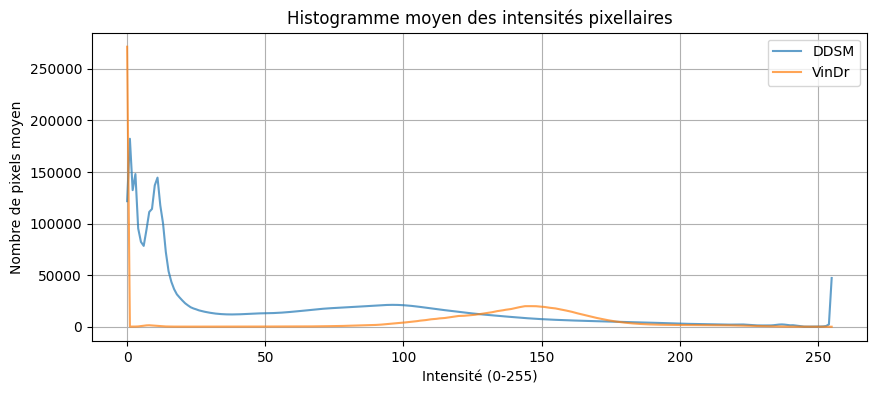

In [2]:
# Téléchargement des deux datasets restructurés
!mc cp -r s3/hlegarzic/stat_app/MINI-DDSM-Complete-JPEG-82/ /home/onyxia/data/ddsm/
!mc cp -r s3/hlegarzic/stat_app/vindr_restructure/ /home/onyxia/data/vindr/

# Calcul des histogrammes moyens
def histogramme_moyen(dossier, extension=('.jpg', '.jpeg', '.png')):
    hist_total = np.zeros(256)
    nb_images = 0
    
    for root, _, files in os.walk(dossier):
        for fname in tqdm(files, desc=os.path.basename(dossier)):
            if fname.endswith(extension):
                img = Image.open(os.path.join(root, fname)).convert('L')
                arr = np.array(img).flatten()
                hist, _ = np.histogram(arr, bins=256, range=(0, 255))
                hist_total += hist
                nb_images += 1
    
    print(f"{nb_images} images traitées")
    return hist_total / nb_images

hist_ddsm = histogramme_moyen("/home/onyxia/data/ddsm/")
hist_vindr = histogramme_moyen("/home/onyxia/data/vindr/")

# Affichage
plt.figure(figsize=(10, 4))
plt.plot(hist_ddsm, label='DDSM', alpha=0.7)
plt.plot(hist_vindr, label='VinDr', alpha=0.7)
plt.xlabel('Intensité (0-255)')
plt.ylabel('Nombre de pixels moyen')
plt.title('Histogramme moyen des intensités pixellaires')
plt.legend()
plt.grid(True)
plt.show()

0it [00:00, ?it/s]
  0%|          | 0/6703 [00:00<?, ?it/s]

100%|██████████| 3296/3296 [01:52<00:00, 29.26it/s]


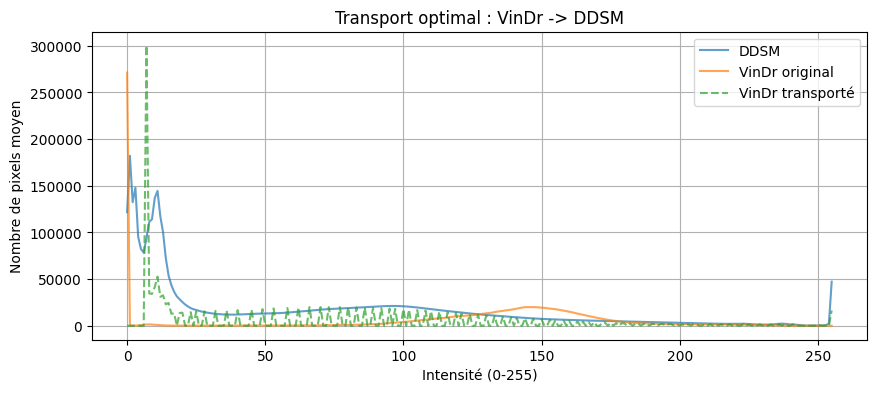

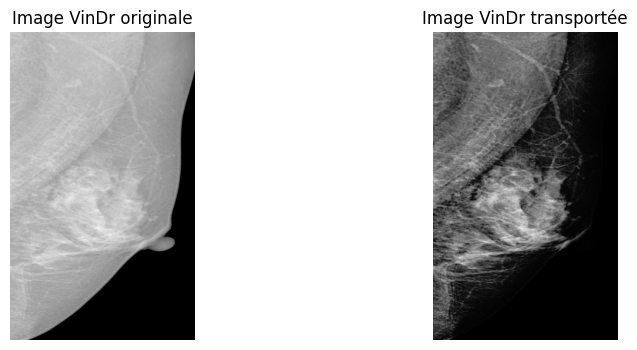

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import os

# Calcul de la fonction de transport optimal (mapping CDF)
def transport_optimal_1d(hist_source, hist_cible):
    p_source = hist_source / hist_source.sum()
    p_cible = hist_cible / hist_cible.sum()
    cdf_source = np.cumsum(p_source)
    cdf_cible = np.cumsum(p_cible)
    mapping = np.zeros(256, dtype=np.float64)
    for i in range(256):
        mapping[i] = np.searchsorted(cdf_cible, cdf_source[i])
    return mapping

def appliquer_transport(img_path, mapping):
    img = Image.open(img_path).convert('L')
    arr = np.array(img)
    arr_transforme = mapping[arr].astype(np.uint8)
    return arr_transforme

# Calcul du mapping VinDr -> DDSM
mapping = transport_optimal_1d(hist_vindr, hist_ddsm)

# Vérification sur une image exemple VinDr
exemple_path = next(
    os.path.join(root, f)
    for root, _, files in os.walk("/home/onyxia/data/vindr/")
    for f in files if f.endswith(('.jpg', '.jpeg', '.png'))
)

img_originale = np.array(Image.open(exemple_path).convert('L'))
img_transformee = appliquer_transport(exemple_path, mapping)

# Histogramme moyen VinDr transformé
hist_vindr_transforme = np.zeros(256)
nb_images = 0
for root, _, files in os.walk("/home/onyxia/data/vindr/"):
    for fname in tqdm(files):
        if fname.endswith(('.jpg', '.jpeg', '.png')):
            arr = appliquer_transport(os.path.join(root, fname), mapping)
            hist, _ = np.histogram(arr, bins=256, range=(0, 255))
            hist_vindr_transforme += hist
            nb_images += 1

hist_vindr_transforme /= nb_images

# Affichage comparatif
plt.figure(figsize=(10, 4))
plt.plot(hist_ddsm, label='DDSM', alpha=0.7)
plt.plot(hist_vindr, label='VinDr original', alpha=0.7)
plt.plot(hist_vindr_transforme, label='VinDr transporté', alpha=0.7, linestyle='--')
plt.xlabel('Intensité (0-255)')
plt.ylabel('Nombre de pixels moyen')
plt.title('Transport optimal : VinDr -> DDSM')
plt.legend()
plt.grid(True)
plt.show()

# Visualisation avant/après sur une image VinDr
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_originale, cmap='gray')
axes[0].set_title('Image VinDr originale')
axes[0].axis('off')
axes[1].imshow(img_transformee, cmap='gray')
axes[1].set_title('Image VinDr transportée')
axes[1].axis('off')
plt.show()

In [4]:
# Application du mapping aux images VinDr
destination_transformee = "/home/onyxia/data/vindr_transforme/"

for classe in ["normal", "cancer_benign"]:
    os.makedirs(os.path.join(destination_transformee, classe), exist_ok=True)

for classe in ["normal", "cancer_benign"]:
    dossier = f"/home/onyxia/data/vindr/{classe}"
    for fname in tqdm(os.listdir(dossier), desc=classe):
        if not fname.endswith(('.jpg', '.jpeg', '.png')):
            continue
        img_path = os.path.join(dossier, fname)
        img_transformee = appliquer_transport(img_path, mapping)
        save_path = os.path.join(destination_transformee, classe, fname)
        Image.fromarray(img_transformee).save(save_path)

# Sauvegarde sur S3
!mc cp -r /home/onyxia/data/vindr_transforme/ s3/hlegarzic/stat_app/vindr_transforme/

cancer_benign: 100%|██████████| 3296/3296 [07:40<00:00,  7.16it/s]


...cdc4dc.png: 4.88 GiB / 4.88 GiB ┃▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓┃ 250.61 MiB/s 19s